### v2 added the lag features including  CH4_w, CH4_skew

In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Model from scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.model_selection import TunedThresholdClassifierCV, TimeSeriesSplit, RandomizedSearchCV

In [3]:
def fill_Nan(df, feature_col):
    df = df.copy()
    for i in feature_col:
        df[i] = df[i].ffill()
    return df
#===========
def ratio_featutre_gen(df):
    df = df.copy()
    df['CH4_area_ht_ratio'] = df['CH4_area']/df['CH4_ht']
    df['CH4_w_ht_ratio'] = df['CH4_w']/df['CH4_ht']
    df['psamp_pflow_ratio'] = df['psamp']/df['pflow']
    df['w_duration_ratio'] = df['CH4_w']/df['duration']

    fill_feature_ratio = ['CH4_area_ht_ratio', 'CH4_w_ht_ratio', 'psamp_pflow_ratio','w_duration_ratio']
    for i in fill_feature_ratio :
        df[i] = df[i].fillna(0)
        
    return df

#=============== diff, lag, rolling
def diff_gen(df, feature, period):
    df = df.copy()
    df[f'{feature}_diff_{period}'] = (df[f'{feature}'].diff(period)).fillna(0)

    return df
#===============
def lag_gen (df, feature, period):
    df = df.copy()
    df[f'{feature}_lag_{period}'] = (df[f'{feature}'].shift(period)).fillna(0)
    return df

#===============
def rolling_std_gen (df, feature, period):
    df = df.copy()
    df[f'{feature}_roll_std_{period}'] = (df[f'{feature}'].rolling(window=pd.to_timedelta(period), closed='left').std()).fillna(0)# self not included, NAN->0
    return df

#===============
def rolling_mean_residual_gen(df, feature, period):
    df = df.copy()
    df[f'{feature}_roll_mean_{period}'] = df[f'{feature}'].rolling(window=pd.to_timedelta(period), closed='left').mean().fillna(0) # self not included
    df[f'{feature}_residual_{period}'] = df[f'{feature}']- df[f'{feature}_roll_mean_{period}']# self not included
    return df


def feature_eng_apply(df, config):
    df = df.copy()

    for opt, params in config.items():
        cols = params['cols']
        period = params.get('period') or params.get('periods', 1) # period's value -> periods's -> 1

        for feature in cols:
            if opt == 'diff':
                df = diff_gen(df, feature, period)
            elif opt == 'lag':
                df = lag_gen(df, feature, period)
            elif opt == 'roll_std':
                df = rolling_std_gen(df, feature, period)
            elif opt == 'roll_mean_res':
                df = rolling_mean_residual_gen(df, feature, period)
    return df 


def best_threshold(X_test, model, y_test):
    y_proba = model.predict_proba(X_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

    f1_scores = 2 * (precisions *recalls) / (precisions + recalls+ 1e-7) # 1e-7 to prevent Nan

    best_idx = np.argmax(f1_scores[:-1])
    best_thres = thresholds[best_idx]

    print(f"Best threshold: {best_thres}")
    print(f"Best F1-score: {f1_scores[best_idx]:.4f}")
    print(f'Precision"{precisions[best_idx]:.4f}", Recall:{recalls[best_idx]}')
   
def plot_importance(model, feature_names, title_suffix=""):
    """
    plotting Feature importance, and upload to MLflow automatically
    """
    print
    importances = pd.Series(model.feature_importances_, index=feature_names)
    importances = importances.sort_values()

    fig, ax = plt.subplots(figsize=(10, 15))
    importances.plot(kind='barh', ax=ax)

    title = f'Feature Importance ({title_suffix})' if title_suffix else "Feature Importance"
    ax.set_title(title)
    fig.tight_layout()

    plt.show()
    plt.close(fig)


def random_forest_model(X_train, y_train, X_test, y_test, feature_names, 
                        experiment_run_name='RF_Model',n_estimators=200, 
                        max_depth=12, n_jobs=-1, threshold=0.5, class_weight=None):
    """
    Fits and evaluate ML models.
    models: dictionary of different ML models
    X_train: training data (no labels)
    X_test: testinh data (no labels)
    y_train: training labels
    y_test: testing labels
    returns model scores dictionary
    """

    model = RandomForestClassifier(
    n_estimators=n_estimators,
    max_depth = max_depth,
    random_state=42,
    n_jobs = n_jobs,
    class_weight=class_weight)


    model.fit(X_train, y_train)

    # evaluation and recording Metrics
    y_proba = model.predict_proba(X_test)[:, 1]
    #y_pred = model.predict(X_test)
    y_pred = (y_proba >= threshold).astype(int) # threshold should be 0.05 or something
    
    acc = accuracy_score(y_test, y_pred)

    print("Model training completed!")
    print(classification_report(y_test, y_pred))

    cm =confusion_matrix(y_test, y_pred, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    fig, ax =plt.subplots(figsize=(6,6))
    disp.plot(ax=ax,cmap=plt.cm.Blues)
    plt.title(f'Normalized Confusion Matrix, threshold:{threshold}')

    plot_path = f'image/0626_confusion_matrix_{threshold}.png' 
    plt.savefig(plot_path)
    plt.show()
    plt.close()
    print(model.feature_importances_)
    return model
    #plot_importance(model, feature_names, title_suffix=experiment_run_name)



[1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007
 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021
 2022 2023 2024 2025]
Model training completed!
              precision    recall  f1-score   support

           0       0.92      1.00      0.96    144705
           1       0.96      0.29      0.44     16938

    accuracy                           0.92    161643
   macro avg       0.94      0.64      0.70    161643
weighted avg       0.93      0.92      0.90    161643



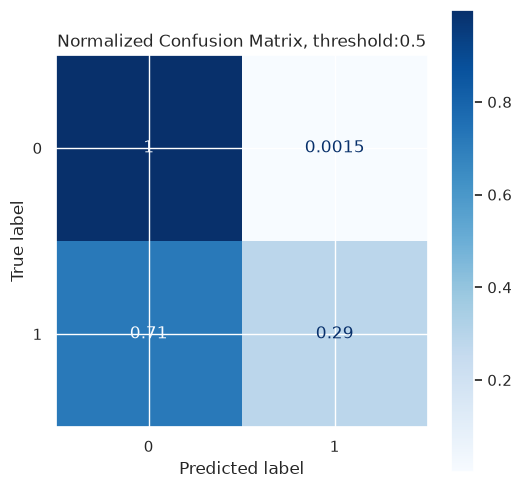

[0.00051314 0.0076523  0.01208198 0.0117854  0.0036019  0.01609963
 0.06136516 0.05614927 0.03644704 0.06194356 0.05545243 0.12192447
 0.01569708 0.01307427 0.06465477 0.05182524 0.09049314 0.02034795
 0.03857004 0.01842214 0.01715864 0.0164193  0.02322286 0.01889098
 0.00053411 0.00734124 0.00673443 0.00352953 0.00366287 0.02774563
 0.01940713 0.00779472 0.0067525  0.00880221 0.01169332 0.00771789
 0.00876704 0.00970296 0.01819527 0.0082289  0.00959758]
Best threshold: 0.15318832956728623
Best F1-score: 0.7169
Precision"0.7087", Recall:0.7252922422954304


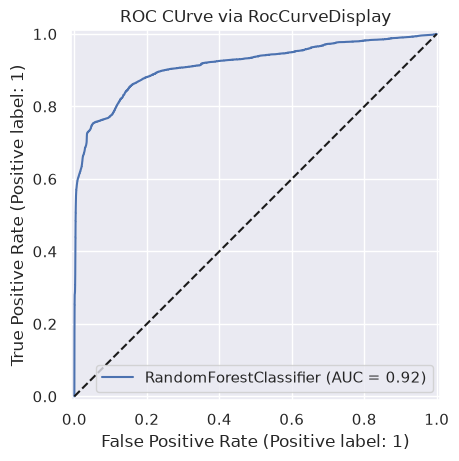

In [10]:
sns.set_theme(style='darkgrid')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df = pd.read_csv('../data/processed/mhd_ch4_simple_v1.csv')
df.head()

df = df.drop(df[df['year']==2026].index)# the latest years'data wouldn't be used
print(df['year'].unique()) 

year_dummies = pd.get_dummies(df['year'], prefix='is_year_').astype(int) # set every year as a features
df= pd.concat([df, year_dummies], axis=1)


df = df.set_index('datetime')
df = df.reset_index()

feature_cols = [
    'datetime',
    #'sample'	,'standard',	
    #'port'	,'ht',
    'tmod'	,'tamb',
    'pflow', 'psamp',
    'pamb'	,
    'CH4_rt',	'CH4_w',	'CH4_ht'	,
    'CH4_area',	'CH4_skew'	,
    'CH4_start_time',	'CH4_end_time'	,'CH4_start_level',	'CH4_end_level',
    'duration', 
]
# 補缺值
df = fill_Nan(df, feature_cols)


X = df[feature_cols]
y = df['label1']
feature_cols = X.columns.tolist()
split_idx = int(len(df)*0.8)


X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Handle nan values, forwardfill


eng_cols = [
    #'sample'	,'standard',	
    #'port'	,'ht',
    'tmod'	,'tamb',
    'pflow', 'psamp',
    'pamb'	,
    'CH4_rt',	'CH4_w',	'CH4_ht'	,
    'CH4_area',	'CH4_skew'	,
    'CH4_start_time',	'CH4_end_time'	,'CH4_start_level',	'CH4_end_level',
    'duration', 
]


X_train_final = X_train.copy()
X_test_final = X_test.copy()

# set date as index
X_train_final  =X_train_final.set_index('datetime')
X_test_final = X_test_final.set_index('datetime')

# fill NAN values
X_train_final = fill_Nan(X_train_final, eng_cols)
X_test_final= fill_Nan(X_test_final, eng_cols)

# create ratio feature
X_train_final  = ratio_featutre_gen(X_train_final)
X_test_final= ratio_featutre_gen(X_test_final)

# conver date index as pd datatime type
X_train_final.index = pd.to_datetime(X_train_final.index)
X_test_final.index = pd.to_datetime(X_test_final.index)



feature_config ={
    'diff':{'cols': ['CH4_area', 'CH4_ht', 'CH4_rt'], 'periods':1},
    'lag':{'cols':['CH4_area', 'CH4_rt', 'tmod', 'tamb','pflow', 'psamp','pamb','CH4_w','CH4_skew'], 'periods':1},
    'roll_std':{'cols': ['CH4_w', 'CH4_skew'], 'period':'14D'},
    'roll_mean_res':{'cols':['CH4_rt', 'CH4_start_time', 'CH4_w', 'CH4_skew'], 'period': '14D'}
}


X_train_final= feature_eng_apply(X_train_final, feature_config)
X_test_final= feature_eng_apply(X_test_final, feature_config)



model_features = ['tmod', 'tamb', 'pflow', 'psamp', 'pamb', 'CH4_rt', 'CH4_w', 'CH4_ht',
       'CH4_area', 'CH4_skew', 'CH4_start_time', 'CH4_end_time',
       'CH4_start_level', 'CH4_end_level', 'duration', 'CH4_area_ht_ratio',
       'CH4_w_ht_ratio', 'psamp_pflow_ratio', 'w_duration_ratio',
       'CH4_area_diff_1', 'CH4_ht_diff_1', 'CH4_rt_diff_1', 
       'CH4_area_lag_1',
       'CH4_rt_lag_1', 'tmod_lag_1', 'tamb_lag_1', 'pflow_lag_1',
       'psamp_lag_1', 'pamb_lag_1','CH4_w_lag_1','CH4_skew_lag_1'
         'CH4_w_roll_std_14D',
       'CH4_skew_roll_std_14D', 'CH4_rt_roll_mean_14D', 'CH4_rt_residual_14D',
       'CH4_start_time_roll_mean_14D', 'CH4_start_time_residual_14D',
       'CH4_w_roll_mean_14D', 'CH4_w_residual_14D', 'CH4_skew_roll_mean_14D',
       'CH4_skew_residual_14D']



# model training

rf_model = random_forest_model(
        X_train_final, y_train, X_test_final,  y_test,
        feature_names=model_features,
        experiment_run_name=f'rf_first_test', n_estimators=200, max_depth=12, n_jobs=-1,
        threshold=0.5,class_weight=None
    )
best_threshold(X_test_final, rf_model, y_test)

RocCurveDisplay.from_estimator(rf_model, X_test_final, y_test)

plt.title('ROC CUrve via RocCurveDisplay')
plt.plot([0, 1], [0,1], 'k--')
plt.show()

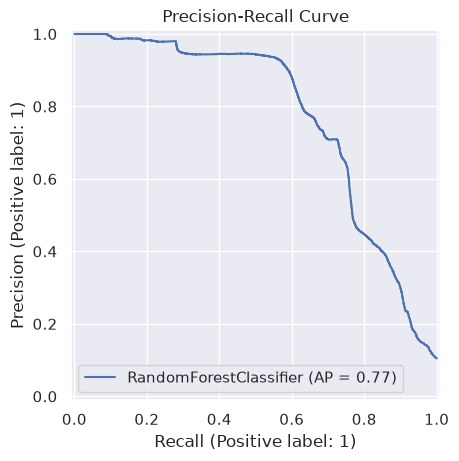

In [11]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(rf_model, X_test_final, y_test)

plt.title('Precision-Recall Curve')
plt.show()

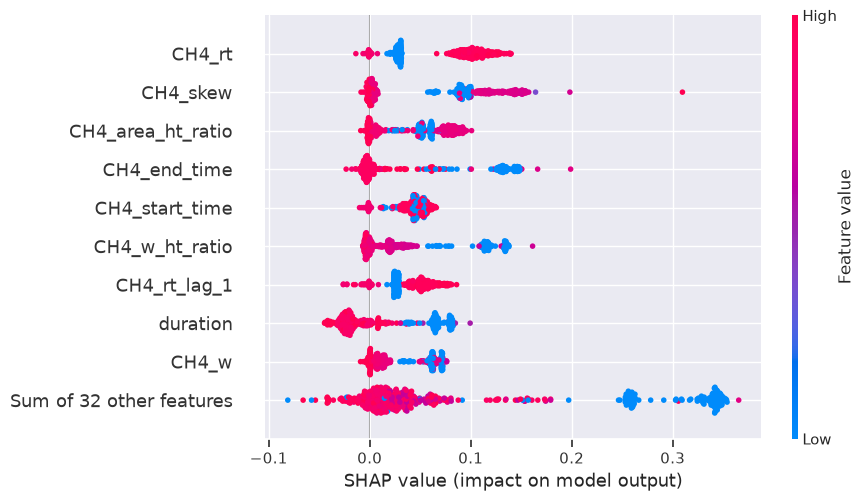

In [12]:
import shap

y_probs = rf_model.predict_proba(X_test_final)[:, 1]

threshold =   0.15318832956728623

X_anomalies = X_test_final[y_probs >= threshold]

#shap
X_sample = shap.utils.sample(X_anomalies, min(len(X_anomalies), 500), random_state=42)

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer(X_sample)
shap.plots.beeswarm(shap_values[:, :, 1])

In [ ]:
pipe_rnd = Pipeline([('scl', StandardScaler()),('clf', RandomForestClassifier(n_estimators=10))])
train_sizes_rnd, train_scores_rnd, test_scores_rnd = learning_curve(estimator=pipe_rnd,X=X, y=y, train_sizes=np.linspace(0.2,1.0,5), cv=5, n_jobs=-1)
train_mean_rnd = np.mean(train_scores_rnd, axis=1)
train_std_rnd = np.std(train_scores_rnd, axis=1)
test_mean_rnd = np.mean(test_scores_rnd, axis=1)
test_std_rnd = np.std(test_scores_rnd, axis=1)



Model training completed!
              precision    recall  f1-score   support

           0       0.96      0.86      0.91    144705
           1       0.38      0.73      0.50     16938

    accuracy                           0.85    161643
   macro avg       0.67      0.79      0.70    161643
weighted avg       0.90      0.85      0.87    161643



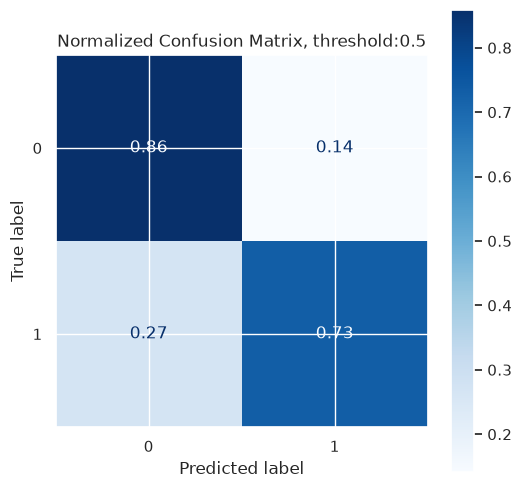

[0.00045042 0.00637199 0.01194146 0.02231541 0.00660724 0.01133996
 0.08957246 0.04871177 0.04821805 0.03624167 0.01884833 0.10076787
 0.01484057 0.02052452 0.06746296 0.06954017 0.02434509 0.02538055
 0.03500442 0.03554669 0.0232968  0.0207228  0.02986404 0.0277716
 0.00047529 0.00952299 0.02436835 0.00415016 0.00609451 0.03615851
 0.01411561 0.0044185  0.00432345 0.00820493 0.02490723 0.00776082
 0.01564866 0.00923807 0.01556089 0.00657495 0.01279021]
Model training completed!
              precision    recall  f1-score   support

           0       0.93      1.00      0.96    144705
           1       0.90      0.34      0.49     16938

    accuracy                           0.93    161643
   macro avg       0.91      0.67      0.73    161643
weighted avg       0.93      0.93      0.91    161643



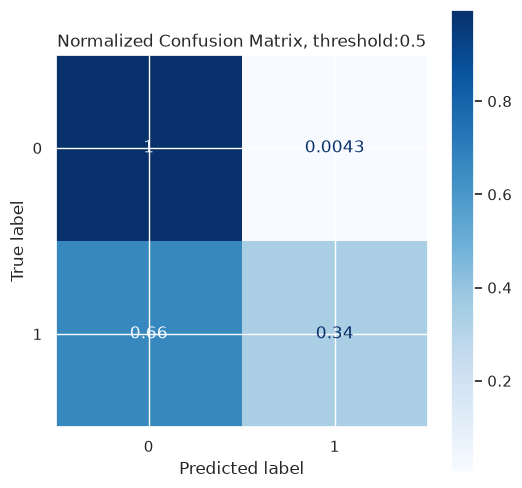

[0.00057636 0.00739942 0.00818185 0.01963837 0.00496803 0.02074791
 0.03895971 0.05136465 0.03617632 0.01954742 0.07961018 0.04860216
 0.00667999 0.00395155 0.03098387 0.03415484 0.07148    0.02023224
 0.112654   0.03189323 0.03200474 0.03256619 0.01693556 0.02578376
 0.0006077  0.00938265 0.00551279 0.00400405 0.00520388 0.03737185
 0.01203317 0.00890038 0.00825611 0.00656952 0.04043517 0.00698099
 0.03737193 0.01230457 0.02362171 0.0079775  0.0183737 ]
Model training completed!
              precision    recall  f1-score   support

           0       0.92      1.00      0.96    144705
           1       0.95      0.29      0.44     16938

    accuracy                           0.92    161643
   macro avg       0.94      0.64      0.70    161643
weighted avg       0.93      0.92      0.90    161643



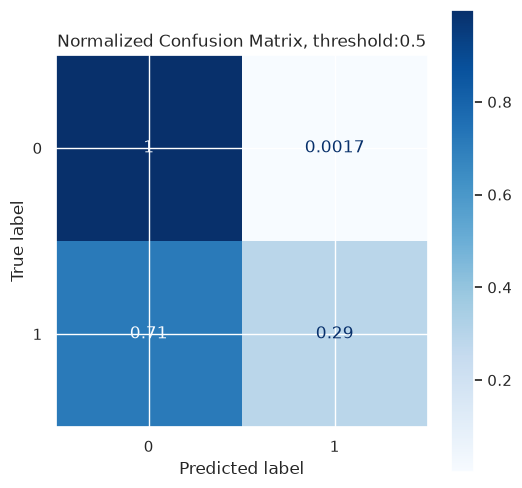

[0.00085143 0.00837107 0.01391866 0.01672738 0.00516522 0.03079449
 0.03705047 0.03993988 0.02504302 0.03098583 0.11222164 0.06752227
 0.0090739  0.00354594 0.04038806 0.03673523 0.08434817 0.03080571
 0.04067323 0.02589738 0.02754032 0.0250637  0.01532682 0.02361865
 0.00075104 0.00853497 0.0060528  0.00443923 0.00446266 0.03116139
 0.01068085 0.00866466 0.00758387 0.00777598 0.04047004 0.00745895
 0.05135209 0.00906329 0.0159748  0.00766287 0.02630202]
Model training completed!
              precision    recall  f1-score   support

           0       0.92      1.00      0.96    144705
           1       0.95      0.29      0.44     16938

    accuracy                           0.92    161643
   macro avg       0.94      0.64      0.70    161643
weighted avg       0.93      0.92      0.90    161643



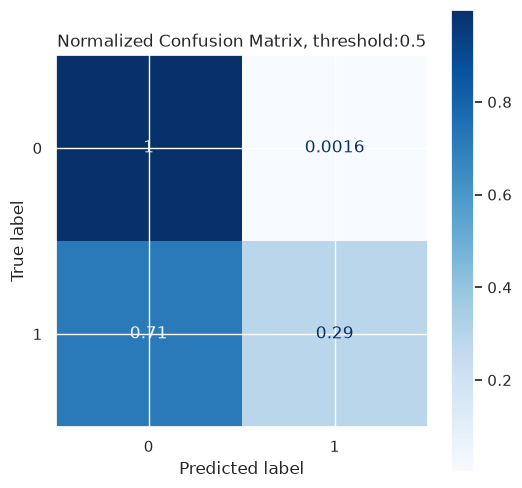

[0.00070251 0.0076511  0.0150219  0.01724354 0.0052762  0.0408253
 0.03984982 0.0384178  0.02292145 0.03519207 0.03854036 0.08435939
 0.00963036 0.00914513 0.05609928 0.034652   0.09203864 0.02669106
 0.04772435 0.02259643 0.02182365 0.02097649 0.01958601 0.02056599
 0.0008162  0.00759714 0.0067752  0.00462657 0.00498729 0.02868
 0.01184532 0.00895934 0.00747464 0.0076092  0.0482659  0.0065934
 0.065302   0.01129595 0.02201473 0.00788618 0.02174012]
Model training completed!
              precision    recall  f1-score   support

           0       0.92      1.00      0.96    144705
           1       0.96      0.29      0.44     16938

    accuracy                           0.92    161643
   macro avg       0.94      0.64      0.70    161643
weighted avg       0.93      0.92      0.90    161643



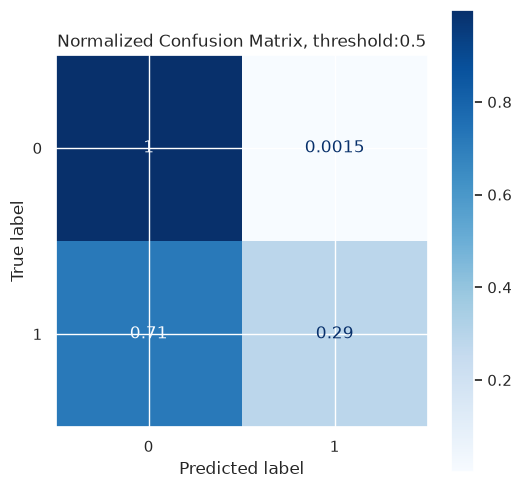

[0.00051314 0.0076523  0.01208198 0.0117854  0.0036019  0.01609963
 0.06136516 0.05614927 0.03644704 0.06194356 0.05545243 0.12192447
 0.01569708 0.01307427 0.06465477 0.05182524 0.09049314 0.02034795
 0.03857004 0.01842214 0.01715864 0.0164193  0.02322286 0.01889098
 0.00053411 0.00734124 0.00673443 0.00352953 0.00366287 0.02774563
 0.01940713 0.00779472 0.0067525  0.00880221 0.01169332 0.00771789
 0.00876704 0.00970296 0.01819527 0.0082289  0.00959758]


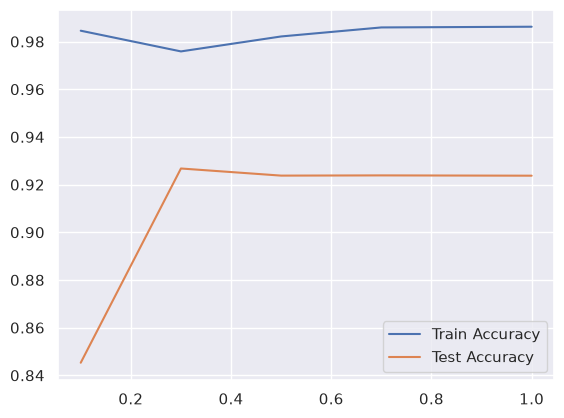

In [8]:
train_sizes = [0.1, 0.3, 0.5, 0.7, 1.0]
train_scores = []
test_scores = []

total_train_size = len(X_train_final)

for size in train_sizes:
    n_samples = int(size * total_train_size)
    X_subset = X_train_final[:n_samples]
    y_subset = y_train[:n_samples]

    model = random_forest_model(
        X_subset, y_subset, X_test_final, y_test,
        feature_names = model_features,
        experiment_run_name=f'rf_size_{size}',
        n_estimators=200,
        max_depth=12,
        n_jobs=-1,
        threshold=0.5,
        class_weight = None
    )
    train_score = model.score(X_subset, y_subset)
    test_score = model.score(X_test_final, y_test)

    train_scores.append(train_score)
    test_scores.append(test_score)


plt.plot(train_sizes, train_scores, label='Train Accuracy')
plt.plot(train_sizes, test_scores, label='Test Accuracy')
plt.legend()
plt.show()

In [9]:
import joblib
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ('rf', rf_model)
])

pipeline.fit(X_train_final, y_train)

joblib.dump(pipeline, 'model/0704_rf_v1.joblib')

['model/0704_rf_v1.joblib']